# Figure 5 |  Dynamics of mangrove canopy cover. 

- Panel **a**, Global pattern of area change (km2) of closed mangrove forests from the 1980s to 2023. The color map indicates the magnitude of change, with blue representing increases and red representing decreases in area. The two red circles highlight the locations of the regional examples detailed in panels b and c (Amazon Macrotidal Mangrove Coast and southwestern Papua, respectively). 

- Panel **b and c**, Regional examples illustrating mangrove change. For each region, the left and middle sub-panels display FCC images from the 1980s and 2023, respectively, where darker green indicates higher canopy cover. The right sub-panels show the change in FCC (ΔFCC = 2023 FCC - 1980s FCC), with greener areas indicating increased FCC (i.e., mangrove growth). 

- Panel **d**, Sankey diagram illustrating the flow and area (km2) of different mangrove canopy types across four time points: 1980s, 2000, 2010, and 2023, which highlights the overall increase in closed mangrove forest area, primarily transferred from open mangrove forests.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import palettable
from tqdm import tqdm
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot
import ee
from geemap import cartoee as cee
import geemap

ee.Authenticate()
ee.Initialize()

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

In [ ]:
os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
df_close1984 = pd.read_csv('Code_Data/ByGrid_Closed1984.csv');df_close2023 = pd.read_csv('Code_Data/ByGrid_Closed2023.csv')
df_all1984 = pd.read_csv('Code_Data/ByGrid_All1984.csv');df_all2023 = pd.read_csv('Code_Data/ByGrid_All2023.csv')

df_close = df_close1984.merge(df_close2023, on="FID", how="outer")  # merge two years of data
df_close = df_close[['FID','AREA_x','AREA_y']]  # only keep necessary columns
df_close.rename(columns={'AREA_x': 'close_1984', 'AREA_y': 'close_2023'}, inplace=True)  # rename columns for clarity

df_all = df_all1984.merge(df_all2023, on="FID", how="outer")  # merge two years of data
df_all = df_all[['FID','AREA_x','AREA_y']]  # only keep necessary columns
df_all.rename(columns={'AREA_x': 'all_1984', 'AREA_y': 'all_2023'}, inplace=True)  # rename columns for clarity

df = df_close.merge(df_all, on="FID", how="outer")  # merge closed and all data
df['percent_closed_1984'] = df['close_1984'] / df['all_1984'] * 100  # calculate percentage closed in 1984
df['percent_closed_2023'] = df['close_2023'] / df['all_2023'] * 100  # calculate percentage close

gdf_grids = gpd.read_file('Code_Data/Grids_1degree.shp') # Read the grid shapefile
gdf_grids = gdf_grids[['ID','geometry']] # Select the columns we need
gdf = gdf_grids.merge(df, left_on='ID', right_on='FID', how='left')
gdf.dropna(inplace=True)  # Drop rows where geometry is NaN
gdf['delta_closed'] = gdf['percent_closed_2023'] - gdf['percent_closed_1984']  # Calculate the change in closed percentage
gdf.index = range(len(gdf))  # Reset index to ensure it starts from 0

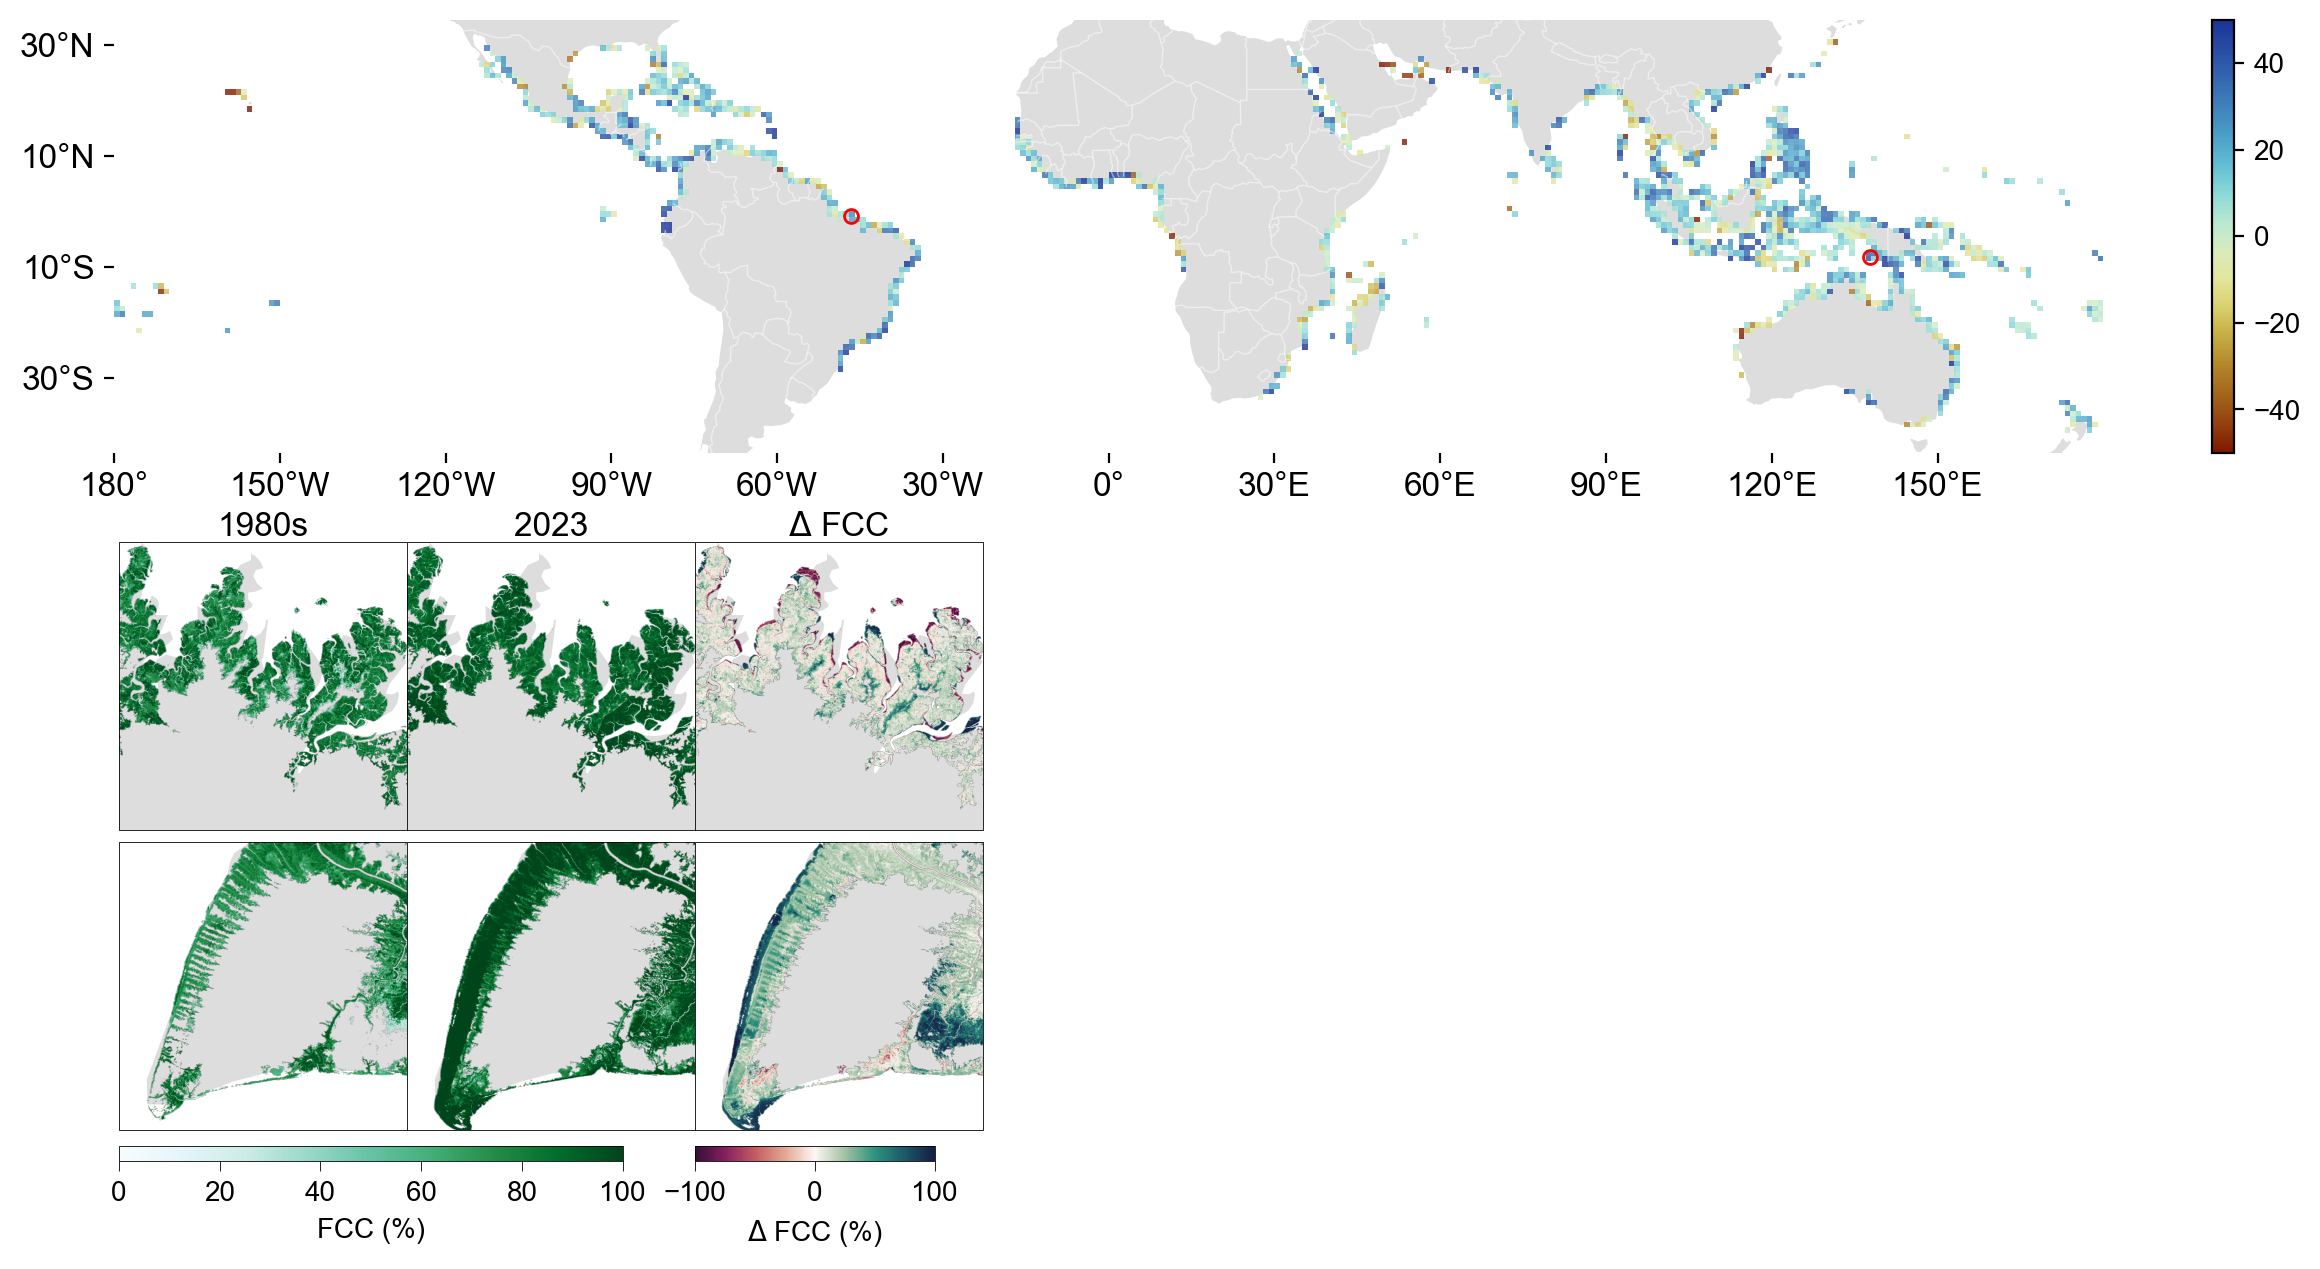

In [ ]:
from shapely.geometry import box
cmap = palettable.scientific.diverging.Roma_16.mpl_colormap

fig = plt.figure(figsize=(12, 2.5),constrained_layout=True)
gs = GridSpec(nrows=1, ncols=1,figure=fig)

ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ZhenPlot.add_basemap(ax1,xticks=True,yticks=True,xrange=np.arange(-180,180,30),fontsize=12)
gdf.plot(column='delta_closed', ax=ax1, cmap=cmap,vmin=-50,vmax=50, legend=True, linewidth=0.5, alpha=0.8)
ax1.set_frame_on(False)
ax1.plot(-46.65, -0.87, 'o', markersize=5, markerfacecolor='none',  markeredgecolor='red', transform=ccrs.PlateCarree())
ax1.plot(137.74,-8.18, 'o', markersize=5, markerfacecolor='none',  markeredgecolor='red', transform=ccrs.PlateCarree())

lon,lat = -46.65,-0.87 #Amazon mangroves
regionpoint = ee.Geometry.Point([lon,lat])
grid = ee.FeatureCollection('projects/ee-wangxyyuyy/assets/GlobalMangroveDynamic/MF_grids_selected')
extent = grid.filterBounds(regionpoint)

mgf1984 = ee.FeatureCollection('projects/mangrovedatahub/assets/AnnualMap/projected_1984')
mgf2023 = ee.FeatureCollection('projects/mangrovedatahub/assets/AnnualMap/projected_2023')
mgf_merged = mgf1984.merge(mgf2023)
FCC1984 = ee.Image('projects/mangrovedatahub/assets/FCC/SouthAmerica/FCC_1984')
FCC2023 = ee.Image('projects/ee-samericamgf/assets/AnnualMGF/Belem-Cururupu/2023').select('FVC').multiply(100)
fcc_delta = FCC2023.subtract(FCC1984)
colors = palettable.colorbrewer.sequential.BuGn_9.hex_colors
colors_divergent = palettable.cmocean.diverging.Curl_9_r.hex_colors

ax_inset1 = fig.add_axes([0.085,-0.7,0.12,0.7], projection=ccrs.PlateCarree())
cee.add_layer(ax_inset1,FCC1984.clip(mgf1984),region = [-46.6,-1.1,-47,-0.7],vis_params = {'min':0,'max':100,'palette':colors},zorder=2)
ax_inset1.set_title('1980s', fontsize=12, loc='center', pad=0.5)

ax_inset2 = fig.add_axes([0.085+0.12,-0.7,0.12,0.7], projection=ccrs.PlateCarree())
cee.add_layer(ax_inset2,FCC2023.clip(mgf2023),region = [-46.6,-1.1,-47,-0.7],vis_params = {'min':0,'max':100,'palette':colors},zorder=2)
ax_inset2.set_title('2023', fontsize=12, loc='center', pad=0.5)

ax_inset3 = fig.add_axes([0.085+0.24,-0.7,0.12,0.7], projection=ccrs.PlateCarree())
cee.add_layer(ax_inset3,fcc_delta.clip(mgf_merged.filterBounds(extent)),region = [-46.6,-1.1,-47,-0.7],vis_params = {'min':-100,'max':100,'palette':colors_divergent},zorder=2)
ax_inset3.set_title('$\Delta$ FCC', fontsize=12, loc='center', pad=0.5)

lon,lat = 137.74,-8.18 #Indonesia mangroves
regionpoint = ee.Geometry.Point([lon,lat])
extent = grid.filterBounds(regionpoint)
FCC1984 = ee.Image('projects/mangrovedatahub/assets/FCC/SEA/FCC_1987') # Our FCC layers can be directly used through GEE
FCC2023 = ee.Image('projects/mangrovedatahub/assets/FCC/SEA/FCC_2023')
fcc_delta = FCC2023.subtract(FCC1984)
region_plotted = ZhenPlot.generating_extent([lon,lat],square=True,xresolution=0.1,yresolution=0.1)
minx,maxx,miny,maxy = region_plotted

ax_inset4 = fig.add_axes([0.085,-1.3,0.12,0.7], projection=ccrs.PlateCarree())
cee.add_layer(ax_inset4,FCC1984.clip(mgf1984),region = [138,-8.46,137.6,-8.06],vis_params = {'min':0,'max':100,'palette':colors},zorder=2)

ax_inset5 = fig.add_axes([0.085+0.12,-1.3,0.12,0.7], projection=ccrs.PlateCarree())
cee.add_layer(ax_inset5,FCC2023.clip(mgf2023),region = [138,-8.46,137.6,-8.06],vis_params = {'min':0,'max':100,'palette':colors},zorder=2)

ax_inset6 = fig.add_axes([0.085+0.24,-1.3,0.12,0.7], projection=ccrs.PlateCarree())
cee.add_layer(ax_inset6,fcc_delta.clip(mgf_merged.filterBounds(extent)),region = [138,-8.46,137.6,-8.06],vis_params = {'min':-100,'max':100,'palette':colors_divergent},zorder=2)

for ax in [ax_inset1, ax_inset2, ax_inset3, ax_inset4, ax_inset5, ax_inset6]:
    ZhenPlot.add_basemap(ax,xticks=False,yticks=False,fontsize=10)
    ZhenPlot.spine_setting(ax,0.3)

ax_cb1 = fig.add_axes([0.085,-1.3,0.21,0.03])
ax_cb2 = fig.add_axes([0.085+0.24,-1.3,0.1,0.03])
cee.add_colorbar(ax_inset1,{'min':0,'max':100,'palette':colors},
                        cax = ax_cb1,
                        orientation='horizontal',
                        label='FCC (%)',
                        label_font_size=10)

cee.add_colorbar(ax_inset3,{'min':-100,'max':100,'palette':colors_divergent},
                        cax = ax_cb2,
                        orientation='horizontal',
                        label='$\Delta$ FCC (%)',
                        label_font_size=10)
ZhenPlot.spine_setting(ax_cb1,0.3); ZhenPlot.spine_setting(ax_cb2,0.3)
plt.savefig("Figures/Fig4.pdf", dpi=500, format='pdf', bbox_inches='tight')

## Sankey diagram

We use the Python Package, Plotly, to draw the Sankey diagram. Because the figure objects of Plotly cannot be grouped with axes from Matplotlib directly, we independently exported them, and then grouped them in Adobe Illustrator.

In [7]:
import plotly.graph_objects as go

df = pd.read_excel(r"D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\Tables\Reclassify4Sankey2.xlsx")
df.head(10)

,Source,Sink,Period,Area_v1,Area_v2
0,closed mangrove forest,closed mangrove forest,1,59118.0166,59158.765390
1,closed mangrove forest,open mangrove forest,1,12841.3500,13166.688760
2,closed mangrove forest,mangrove woodland,1,1461.3800,1553.123142
3,closed mangrove forest,sparse mangrove,1,326.9500,333.213818
4,closed mangrove forest,others,1,3203.2200,3386.674266
5,open mangrove forest,closed mangrove forest,1,19445.2600,19339.609940
6,open mangrove forest,open mangrove forest,1,32037.8400,31688.814790
7,open mangrove forest,mangrove woodland,1,4568.1400,4560.732795
8,open mangrove forest,sparse mangrove,1,202.5668,203.648908
9,open mangrove forest,others,1,2336.0556,2422.478159


In [ ]:
value = df[df['Period']<=3]['Area_v2']
alpha = 0.2
link_colors = [f'rgba(0,117,178,{alpha})',f'rgba(185, 230, 248,{alpha})',f'rgba(234, 156, 155,{alpha})',f'rgba(206, 214, 119,{alpha})',f'rgba(217, 222, 231,{alpha})']
colors = ["#0074b3",'#b9e5fa','#ea9c9d','#d4d66d','#d9dee7']
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 10,
      thickness = 10,
      line = dict(color = "white", width = 0.5),
      x = [0.001]*5+[0.35]*5+[0.65]*5+[1]*5,
      y = [0.001,0.4,0.65,0.75,0.85]*5,
      label = ["Closed mangroves", "Open mangroves", "Mangrove woodland", "Sparse mangroves", "Others"]*4,
      color = colors*5,
    ),
    link = dict(
      source = [0]*5+[1]*5+[2]*5+[3]*5+[4]*4+[5]*5+[6]*5+[7]*5+[8]*5+[9]*4+[10]*5+[11]*5+[12]*5+[13]*5+[14]*4,
      target = [5,6,7,8,9]*4+[5,6,7,8]+[10,11,12,13,14]*4+[10,11,12,13]+[15,16,17,18,19]*4+[15,16,17,18],
      value = value,
      color = link_colors*4+link_colors[:-1]+link_colors*4+link_colors[:-1]+link_colors*4+link_colors[:-1]
  ))])

fig.update_layout(
    title_text="",
    font_family="arial",
    font_color="black",
    font_size=7,
)
fig.show()


In [ ]:
fig.write_image("Figures/sankey2.pdf")